In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

data = pd.read_csv('./data/Housing.csv')

X = data['area'].values
y = data['price'].values


X_train, X_test, y_train, y_test = train_test_split(X ,y, test_size=0.2, random_state=42)

#NORMALIZATION DATA : makes values small / close to zero so i can calculate (in between 0 and 1)
X_train = X_train / X_train.max()
y_train = y_train / y_train.max()
X_test = X_test / X_test.max()
y_test = y_test / y_test.max()

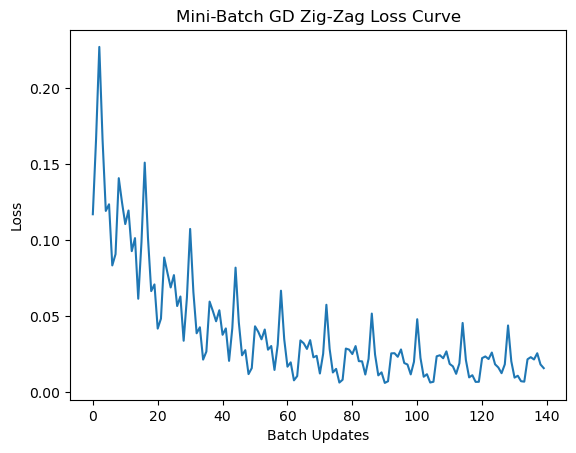

In [2]:
m = 0
b = 0
learning_rate = 0.01
epochs = 10

# Create batches 

batch_size = 32
batch_test_mse = []

n = len(X_train)

for i in range(epochs):

  for start in range(0, n, batch_size):
         
         X_batch = X_train[start:start+batch_size]
         y_batch = y_train[start:start+batch_size]

         y_pred = m * X_batch + b

         batch_n = len(X_batch)
         
         dm = (-2/batch_n) * np.sum(X_batch * (y_batch - y_pred))
         db = (-2/batch_n) * np.sum(y_batch - y_pred)
    
         #  print("ERROR m: " , dm)
         #  print("ERROR b: " , db)

         m = m - learning_rate * dm
         b = b - learning_rate * db
   
         loss = np.mean((y_batch - (m * X_batch + b)) ** 2)
         batch_test_mse.append(loss)

plt.plot(batch_test_mse)
plt.xlabel("Batch Updates")
plt.ylabel("Loss")
plt.title("Mini-Batch GD Zig-Zag Loss Curve")
plt.show()

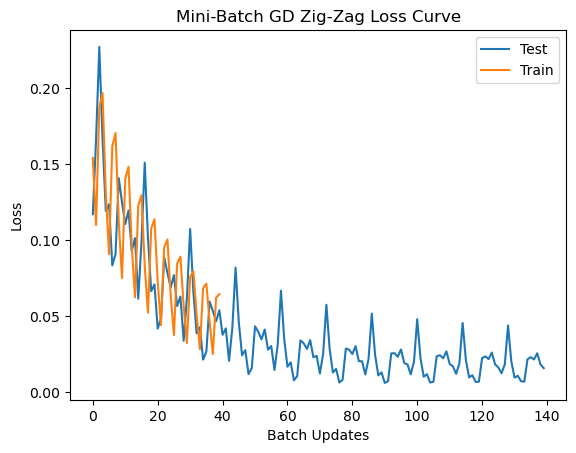

In [3]:
m = 0
b = 0
learning_rate = 0.01
epochs = 10

# Create batches 

batch_size = 32
batch_train_mse = []

n = len(X_test)

for i in range(epochs):

  for start in range(0, n, batch_size):
         
         X_batch = X_test[start:start+batch_size]
         y_batch = y_test[start:start+batch_size]

         y_pred = m * X_batch + b

         batch_n = len(X_batch)
         
         dm = (-2/batch_n) * np.sum(X_batch * (y_batch - y_pred))
         db = (-2/batch_n) * np.sum(y_batch - y_pred)
    
         #  print("ERROR m: " , dm)
         #  print("ERROR b: " , db)

         m = m - learning_rate * dm
         b = b - learning_rate * db
   
         loss = np.mean((y_batch - (m * X_batch + b)) ** 2)
         batch_train_mse.append(loss)

plt.plot(batch_test_mse , label ="Test")
plt.plot(batch_train_mse , label = "Train")
plt.xlabel("Batch Updates")
plt.ylabel("Loss")
plt.title("Mini-Batch GD Zig-Zag Loss Curve")
plt.legend()
plt.show()